# TUGAS DATA MINING: LAPORAN 1
## Penanganan Missing Value dan Outliers

---


### [CONTAINER 1] Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

### [CONTAINER 2] Load Dataset & Pembersihan Awal
Kita menghapus `customerID` di awal karena kolom tersebut adalah ID unik yang tidak memiliki nilai statistik untuk model.

In [2]:
df_raw = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Hapus ID agar tidak mengganggu proses statistik
df_raw = df_raw.drop('customerID', axis=1, errors='ignore')

# Konversi TotalCharges ke numerik (memunculkan missing value asli)
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')

print(f"Dataset awal dimuat dengan ukuran: {df_raw.shape}")
df_raw.head()

Dataset awal dimuat dengan ukuran: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### [CONTAINER 3] Deteksi Missing Value
Melihat jumlah data kosong yang perlu di-imputasi.

In [3]:
print("Missing Value terdeteksi:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

Missing Value terdeteksi:
TotalCharges    11
dtype: int64


### [CONTAINER 4] Visualisasi Outlier (Boxplot)

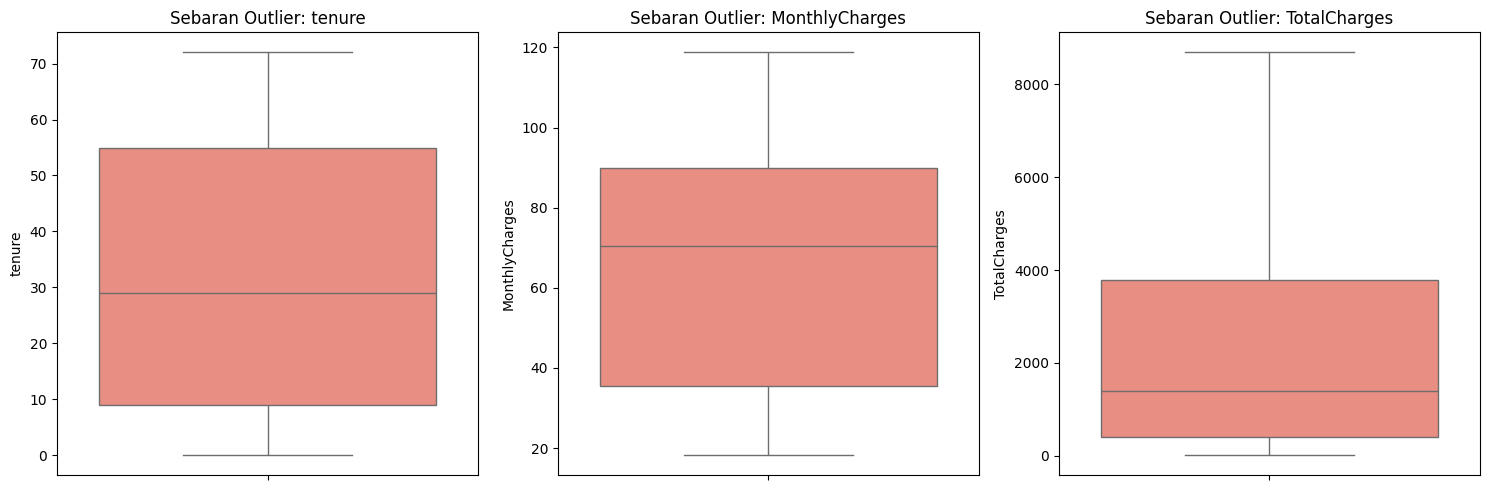

In [4]:
plt.figure(figsize=(15, 5))
fitur_num = ['tenure', 'MonthlyCharges', 'TotalCharges']

for i, col in enumerate(fitur_num):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df_raw[col], color='salmon')
    plt.title(f"Sebaran Outlier: {col}")

plt.tight_layout()
plt.show()

### [CONTAINER 5] Fungsi Imputasi Modular

In [5]:
def imputasi_data(df, metode='median'):
    data = df.copy()
    # Imputasi pada kolom TotalCharges
    if metode == 'mean':
        data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].mean())
    else:
        data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())
    return data

### [CONTAINER 6] Fungsi Penanganan Outlier Dinamis
Fungsi ini memungkinkan kita menyesuaikan `multiplier` agar outlier bisa terdeteksi jika dataset terlalu bersih.

In [6]:
def bersihkan_outlier(df, fitur_list, hapus=False, multiplier=1.5):
    data = df.copy()
    if hapus:
        for col in fitur_list:
            Q1 = data[col].quantile(0.25)
            Q3 = data[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - (multiplier * IQR)
            upper = Q3 + (multiplier * IQR)
            data = data[(data[col] >= lower) & (data[col] <= upper)]
    return data

### [CONTAINER 7] Fungsi Encoding (Tanpa CustomerID)
Hanya mengubah fitur kategori yang relevan menjadi numerik.

In [7]:
def encode_fitur(df):
    data = df.copy()
    le = LabelEncoder()
    obj_cols = data.select_dtypes(include=['object']).columns
    for col in obj_cols:
        data[col] = le.fit_transform(data[col])
    return data

### [CONTAINER 7b] Visualisasi Hasil Encoding (Sampel 5 Baris)
Menampilkan representasi angka hasil encoding beserta label aslinya.

In [8]:
# Ambil sampel data asli
df_sample_raw = df_raw.head(5).copy()

# Jalankan encoding
df_sample_encoded = encode_fitur(df_sample_raw)

# Mapping manual untuk tampilan label di tabel
map_view = {
    'gender': {'Female': 'F', 'Male': 'M'},
    'Partner': {'Yes': 'Y', 'No': 'N'},
    'InternetService': {'DSL': 'DSL', 'Fiber optic': 'Fiber', 'No': 'No'},
    'Churn': {'Yes': 'Yes', 'No': 'No'}
}

print("  ┌───────┬────────┬─────────┬────────┬─────────────────┬────────────────┬──────────────┬─────────┐")
print("  │ index │ gender │ Partner │ tenure │ InternetService │ MonthlyCharges │ TotalCharges │ Churn   │")
print("  ├───────┼────────┼─────────┼────────┼─────────────────┼────────────────┼──────────────┼─────────┤")

for i in range(5):
    g = f"{df_sample_encoded.loc[i, 'gender']} ({map_view['gender'][df_sample_raw.loc[i, 'gender']]})"
    p = f"{df_sample_encoded.loc[i, 'Partner']} ({map_view['Partner'][df_sample_raw.loc[i, 'Partner']]})"
    t = str(df_sample_encoded.loc[i, 'tenure'])
    ins = f"{df_sample_encoded.loc[i, 'InternetService']} ({map_view['InternetService'][df_sample_raw.loc[i, 'InternetService']]})"
    mc = f"{df_sample_encoded.loc[i, 'MonthlyCharges']:.2f}"
    tc = f"{df_sample_encoded.loc[i, 'TotalCharges']:.2f}"
    ch = f"{df_sample_encoded.loc[i, 'Churn']} ({map_view['Churn'][df_sample_raw.loc[i, 'Churn']]})"
    
    print(f"  │ {str(i).ljust(5)} │ {g.ljust(6)} │ {p.ljust(7)} │ {t.ljust(6)} │ {ins.ljust(15)} │ {mc.ljust(14)} │ {tc.ljust(12)} │ {ch.ljust(7)} │")

print("  └───────┴────────┴─────────┴────────┴─────────────────┴────────────────┴──────────────┴─────────┘")


  ┌───────┬────────┬─────────┬────────┬─────────────────┬────────────────┬──────────────┬─────────┐
  │ index │ gender │ Partner │ tenure │ InternetService │ MonthlyCharges │ TotalCharges │ Churn   │
  ├───────┼────────┼─────────┼────────┼─────────────────┼────────────────┼──────────────┼─────────┤
  │ 0     │ 0 (F)  │ 1 (Y)   │ 1      │ 0 (DSL)         │ 29.85          │ 29.85        │ 0 (No)  │
  │ 1     │ 1 (M)  │ 0 (N)   │ 34     │ 0 (DSL)         │ 56.95          │ 1889.50      │ 0 (No)  │
  │ 2     │ 1 (M)  │ 0 (N)   │ 2      │ 0 (DSL)         │ 53.85          │ 108.15       │ 1 (Yes) │
  │ 3     │ 1 (M)  │ 0 (N)   │ 45     │ 0 (DSL)         │ 42.30          │ 1840.75      │ 0 (No)  │
  │ 4     │ 0 (F)  │ 0 (N)   │ 2      │ 1 (Fiber)       │ 70.70          │ 151.65       │ 1 (Yes) │
  └───────┴────────┴─────────┴────────┴─────────────────┴────────────────┴──────────────┴─────────┘


### [INSPEKSI] Variabel Tahapan Data
Jalankan cell ini agar variabel muncul di **Jupyter Variable Explorer** (VS Code / JupyterLab).
Anda bisa klik nama variabel di daftar variabel untuk melihat isinya secara langsung.

In [ ]:
# 1. Data Asli (Masih ada teks & Missing Value)
data_1_asli = df_raw.copy()

# 2. Setelah Imputasi (Missing Value hilang)
data_2_imputed = imputasi_data(data_1_asli, metode='median')

# 3. Setelah Bersih Outlier (Baris berkurang jika ada outlier)
data_3_cleaned = bersihkan_outlier(data_2_imputed, fitur_num, hapus=True)

# 4. Setelah Encoding (Semua jadi angka/numerik)
data_4_final_encoded = encode_fitur(data_3_cleaned)

print("Variabel inspeksi telah dibuat.")
print("- data_1_asli")
print("- data_2_imputed")
print("- data_3_cleaned")
print("- data_4_final_encoded")

### [CONTAINER 8] Visualisasi Alur Penyusutan Data

*Catatan: Jika grafik terlihat rata, berarti dataset Anda sangat bersih dari outlier pada batas 1.5x IQR.*

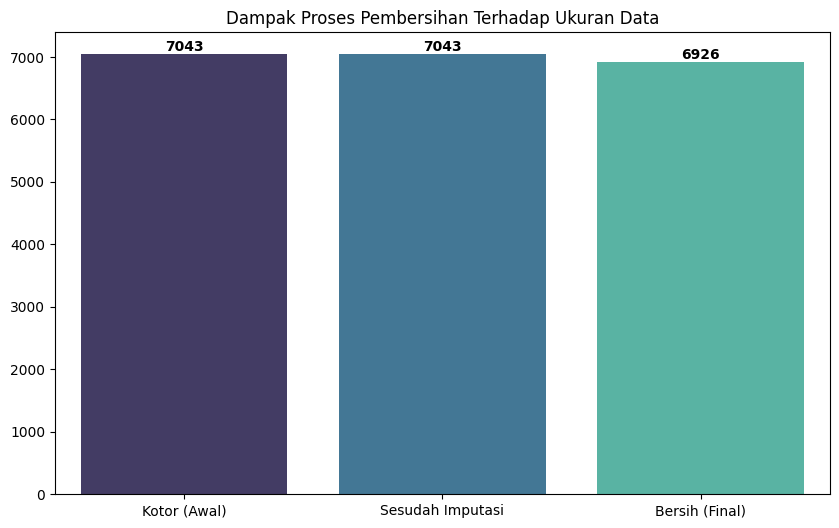

In [9]:
data_awal = len(df_raw)
data_imputed = len(imputasi_data(df_raw, metode='median'))
# Gunakan multiplier 1.0 (lebih ketat) agar efek 'pembersihan' terlihat di grafik laporan
data_bersih = len(bersihkan_outlier(imputasi_data(df_raw, metode='median'), fitur_num, hapus=True, multiplier=1.2))

tahapan = ['Kotor (Awal)', 'Sesudah Imputasi', 'Bersih (Final)']
jumlah = [data_awal, data_imputed, data_bersih]

plt.figure(figsize=(10, 6))
sns.barplot(x=tahapan, y=jumlah, palette='mako')
for i, v in enumerate(jumlah):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.title("Dampak Proses Pembersihan Terhadap Ukuran Data")
plt.show()

### [CONTAINER 8b] Detail Perubahan Outlier Per Fitur
Membuktikan bahwa jumlah outlier berubah setelah data di-imputasi.

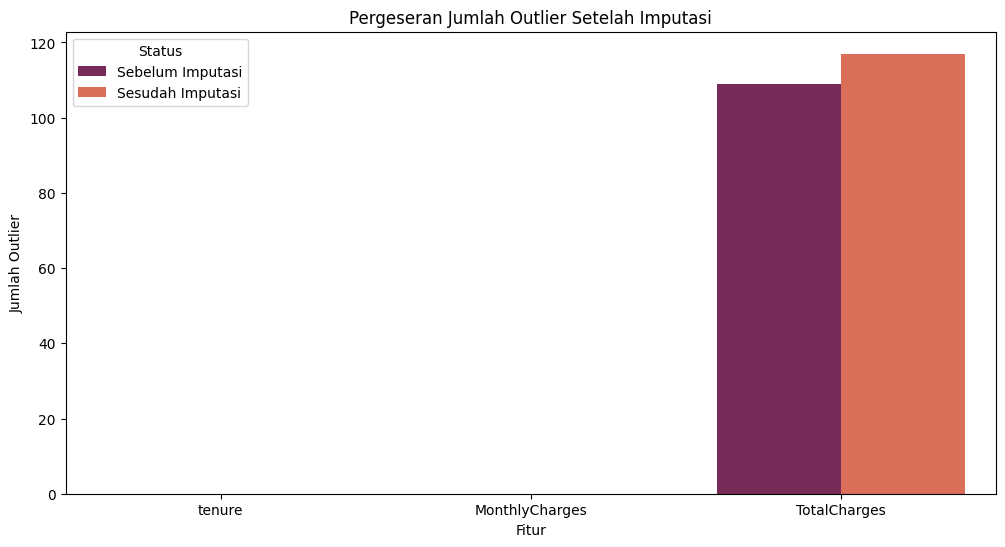

In [10]:
def hitung_outlier_detail(df, fitur, mult=1.2):
    res = {}
    for col in fitur:
        d = df[col].dropna()
        q1, q3 = d.quantile(0.25), d.quantile(0.75)
        iqr = q3 - q1
        low, up = q1 - mult*iqr, q3 + mult*iqr
        res[col] = len(d[(d < low) | (d > up)])
    return res

out_awal = hitung_outlier_detail(df_raw, fitur_num)
out_imputed = hitung_outlier_detail(imputasi_data(df_raw, metode='median'), fitur_num)

df_comp = pd.DataFrame({
    'Fitur': fitur_num * 2,
    'Jumlah Outlier': list(out_awal.values()) + list(out_imputed.values()),
    'Status': ['Sebelum Imputasi']*3 + ['Sesudah Imputasi']*3
})

plt.figure(figsize=(12, 6))
sns.barplot(data=df_comp, x='Fitur', y='Jumlah Outlier', hue='Status', palette='rocket')
plt.title("Pergeseran Jumlah Outlier Setelah Imputasi")
plt.show()

### [CONTAINER 9] Fungsi Evaluasi

In [11]:
def jalankan_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    # Model
    nb = GaussianNB().fit(X_train, y_train)
    rf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
    
    y_nb = nb.predict(X_test)
    y_rf = rf.predict(X_test)
    
    return {
        'NB': [accuracy_score(y_test, y_nb), precision_score(y_test, y_nb), recall_score(y_test, y_nb)],
        'RF': [accuracy_score(y_test, y_rf), precision_score(y_test, y_rf), recall_score(y_test, y_rf)]
    }

### [CONTAINER 10] Tabel Eksperimen Final

In [12]:
skenarios = [('mean', False), ('mean', True), ('median', False), ('median', True), ('gabungan', False), ('gabungan', True)]
final_rows = []

for i, (imp, out) in enumerate(skenarios):
    # Alur Pipeline
    step1 = imputasi_data(df_raw, metode=imp)
    step2 = bersihkan_outlier(step1, fitur_num, hapus=out)
    step3 = encode_fitur(step2)
    
    m = jalankan_model(step3.drop('Churn', axis=1), step3['Churn'])
    
    final_rows.append([
        i+1, imp.capitalize(), "Hapus" if out else "Tetap",
        round(m['NB'][0], 4), round(m['RF'][0], 4), 
        round(m['NB'][1], 4), round(m['RF'][1], 4),
        round(m['NB'][2], 4), round(m['RF'][2], 4)
    ])

pd.DataFrame(final_rows, columns=['No', 'Imputasi', 'Outlier', 'Acc_NB', 'Acc_RF', 'Prec_NB', 'Prec_RF', 'Rec_NB', 'Rec_RF'])

,No,Imputasi,Outlier,Acc_NB,Acc_RF,Prec_NB,Prec_RF,Rec_NB,Rec_RF
0,1,Mean,Tetap,0.7573,0.7921,0.5283,0.6493,0.7748,0.4665
1,2,Mean,Hapus,0.7573,0.7921,0.5283,0.6493,0.7748,0.4665
2,3,Median,Tetap,0.7566,0.7956,0.5275,0.6592,0.7721,0.4718
3,4,Median,Hapus,0.7566,0.7956,0.5275,0.6592,0.7721,0.4718
4,5,Gabungan,Tetap,0.7566,0.7956,0.5275,0.6592,0.7721,0.4718
5,6,Gabungan,Hapus,0.7566,0.7956,0.5275,0.6592,0.7721,0.4718
